# Capstone Project - Final Analysis
## Industry Growth Prediction | California EDD Labor Market Data
**Berkeley Engineering | Berkeley Haas - Module 24 Final Submission**

**Author:** Graycloud Rios  
**Dataset:** California Employment Development Department (EDD) - Labor Market Information Division  
**Task Type:** Binary Classification  
**Target Variable:** `GrowthLabel` - Will an industry grow (1) or decline (0) next year?

---


## 1. Problem Statement

California's labor market spans hundreds of industries, each with its own employment trajectory.
Workforce development boards, policymakers, job seekers, and economic planners need reliable signals
to identify which industries are likely to expand or contract in the coming year.

**Research Question:**  
*Can historical employment patterns - including trends, year-over-year changes, and seasonal variation -
predict whether a California industry will grow or decline in employment in the next year?*

This project frames the question as a **binary classification** task:
- **Target (`GrowthLabel`):** `1` if next-year annual average employment exceeds the current year; `0` otherwise
- **Data Source:** Monthly employment by NAICS industry from the California EDD LMID (2010–2025)
- **Primary Metric:** F1-score (balances precision and recall under mild class imbalance)
- **Secondary Metric:** ROC-AUC


## 2. Setup

In [1]:
# Core
import re
import warnings
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score, RocCurveDisplay
)

warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (12, 5)
sns.set_theme(style="whitegrid")
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 3. Data Loading

The dataset is sourced from the California EDD Labor Market Information Division (LMID).
It contains monthly employment counts for 282 industry classifications spanning January 2010 through August 2025 - 188 months total.


In [2]:
DATA_PATH = "EDD-Data.csv"
df_raw = pd.read_csv(DATA_PATH)
df_raw.columns = [c.strip() for c in df_raw.columns]

month_cols = [c for c in df_raw.columns
              if re.match(r"^(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)-\d{2}$", c)]
id_cols    = [c for c in df_raw.columns if c not in month_cols]

print(f"Raw shape      : {df_raw.shape}")
print(f"Month columns  : {len(month_cols)}  ({month_cols[0]} → {month_cols[-1]})")
print(f"ID columns     : {id_cols}")
df_raw.head(3)


Raw shape      : (286, 196)
Month columns  : 188  (Jan-10 → Aug-25)
ID columns     : ['SORTORDER', 'BMYEAR', 'AREA', 'INCLUDES', 'BREAKS', 'PNCO', 'SS-NAICS', 'TITLE']


,SORTORDER,BMYEAR,AREA,INCLUDES,BREAKS,PNCO,SS-NAICS,TITLE,Jan-10,Feb-10,Mar-10,Apr-10,May-10,Jun-10,Jul-10,Aug-10,Sep-10,Oct-10,Nov-10,Dec-10,...,Jan-24,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24,Sep-24,Oct-24,Nov-24,Dec-24,Jan-25,Feb-25,Mar-25,Apr-25,May-25,Jun-25,Jul-25,Aug-25
0,1,2024,0,NaN,NaN,1,00-000010,Civilian Labor Force,"18,305,700","18,378,100","18,407,000","18,364,800","18,318,700","18,339,300","18,431,000","18,428,000","18,407,000","18,333,300","18,363,000","18,286,700",...,"19,499,800","19,628,700","19,667,700","19,509,800","19,526,800","19,591,100","19,759,400","19,722,100","19,771,100","19,724,900","19,696,800","19,630,300","19,702,600","19,737,200","19,844,000","19,818,200","19,808,000","19,771,500","19,825,500","19,939,500"
1,2,2024,0,NaN,NaN,1,00-000020,Civilian Employment,"15,925,100","16,021,100","16,047,700","16,137,000","16,161,800","16,104,300","16,108,300","16,140,900","16,193,200","16,143,700","16,098,700","16,071,800",...,"18,446,000","18,569,600","18,641,600","18,577,000","18,613,600","18,526,800","18,600,400","18,567,700","18,740,900","18,679,100","18,636,800","18,611,400","18,609,500","18,651,200","18,788,900","18,826,900","18,825,700","18,633,900","18,620,600","18,776,300"
2,3,2024,0,NaN,NaN,1,00-000030,Civilian Unemployment,"2,380,600","2,357,000","2,359,300","2,227,800","2,156,900","2,235,000","2,322,800","2,287,100","2,213,800","2,189,600","2,264,300","2,214,900",...,"1,053,800","1,059,100","1,026,100","932,800","913,300","1,064,300","1,159,000","1,154,400","1,030,100","1,045,800","1,060,000","1,018,900","1,093,100","1,086,000","1,055,000","991,300","982,300","1,137,600","1,204,900","1,163,200"


## 4. Data Cleaning

Steps performed:
1. Remove duplicate rows
2. Convert monthly values from string (comma-formatted) to float; mark percentage rows as NaN
3. Drop non-industry rows (Civilian Labor Force, Unemployment Rate, etc.)
4. Retain only rows with ≥ 80% non-null monthly values
5. Impute remaining missing monthly values via row median


In [3]:
def to_number(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().replace(",", "")
    if s.endswith("%"): return np.nan
    try:    return float(s)
    except: return np.nan

df = df_raw.drop_duplicates().copy()

for c in month_cols:
    df[c] = df[c].map(to_number)

bad_patterns = r"Unemployment Rate|Civilian Labor Force|Civilian Employment|Civilian Unemployment"
df = df[~df["TITLE"].astype(str).str.contains(bad_patterns, regex=True, na=False)].copy()

non_null_ratio = df[month_cols].notna().mean(axis=1)
df = df[non_null_ratio >= 0.80].copy()

# Row-median imputation for any remaining NaNs
row_medians = df[month_cols].median(axis=1)
for c in month_cols:
    mask = df[c].isna()
    df.loc[mask, c] = row_medians[mask]

print(f"Cleaned shape  : {df.shape}")
print(f"Remaining NaNs : {df[month_cols].isna().sum().sum()}")


Cleaned shape  : (282, 196)
Remaining NaNs : 0


## 5. Reshape to Long Format

Convert wide monthly columns into a long table (one row per industry × month),
then parse the month string into a proper datetime and extract the year.


In [4]:
df_long = df.melt(
    id_vars=["SS-NAICS", "TITLE"],
    value_vars=month_cols,
    var_name="month",
    value_name="employment"
)
df_long["date"] = pd.to_datetime(df_long["month"], format="%b-%y")
df_long["year"] = df_long["date"].dt.year
df_long = df_long.drop(columns=["month"]).dropna(subset=["employment"])

print(f"Long format shape : {df_long.shape}")
df_long.head(5)


Long format shape : (53016, 5)


,SS-NAICS,TITLE,employment,date,year
0,01-000000,"Total, All Industries",14350700.0,2010-01-01,2010
1,11-000000,Total Farm,301900.0,2010-01-01,2010
2,00-000000,Total Nonfarm,14048800.0,2010-01-01,2010
3,05-000000,Total Private,11604600.0,2010-01-01,2010
4,06-000000,Goods Producing,1799200.0,2010-01-01,2010


## 6. Annual Aggregation

Aggregate monthly employment values into annual statistics per industry.
Years with fewer than 10 reported months are excluded to avoid partial-year distortion.


In [5]:
df_year = (
    df_long.groupby(["SS-NAICS", "TITLE", "year"], as_index=False)
           .agg(
               employment_avg = ("employment", "mean"),
               employment_min = ("employment", "min"),
               employment_max = ("employment", "max"),
               employment_std = ("employment", "std"),
               months         = ("employment", "size")
           )
)
df_year = df_year[df_year["months"] >= 10].sort_values(["SS-NAICS", "year"])
print(f"Annual dataset shape : {df_year.shape}")
df_year.head(6)


Annual dataset shape : (4230, 8)


,SS-NAICS,TITLE,year,employment_avg,employment_min,employment_max,employment_std,months
0,00-000000,Total Nonfarm,2010,1.428332e+07,14048800.0,14494400.0,147660.095705,12
1,00-000000,Total Nonfarm,2011,1.443483e+07,14197900.0,14678300.0,146681.289216,12
2,00-000000,Total Nonfarm,2012,1.476171e+07,14435100.0,15084700.0,198413.024033,12
3,00-000000,Total Nonfarm,2013,1.515104e+07,14796100.0,15498200.0,211875.218244,12
4,00-000000,Total Nonfarm,2014,1.557575e+07,15228900.0,15938900.0,221672.471330,12
5,00-000000,Total Nonfarm,2015,1.605147e+07,15661600.0,16447300.0,250159.059703,12


## 7. Target Variable - `GrowthLabel`

For each (industry, year) pair, the label is defined as:
- **1** - next year's annual average employment is **higher** than the current year (growth)
- **0** - next year's annual average employment is **equal or lower** (decline / stagnation)

The final year per industry is dropped since its next-year value is unknown.


In [6]:
df_year["employment_next_year"] = df_year.groupby("SS-NAICS")["employment_avg"].shift(-1)
df_year["GrowthLabel"] = (df_year["employment_next_year"] > df_year["employment_avg"]).astype(int)
df_model_base = df_year.dropna(subset=["employment_next_year"]).copy()

label_dist = df_model_base["GrowthLabel"].value_counts(normalize=True).rename({1:"Grow (1)", 0:"Decline (0)"})
print("GrowthLabel distribution:")
print(label_dist.round(4))


GrowthLabel distribution:
GrowthLabel
Grow (1)       0.6768
Decline (0)    0.3232
Name: proportion, dtype: float64


## 8. Feature Engineering

### 8.1 - Features Carried Over from Initial EDA
- `employment_lag1` - prior year's employment
- `yoy_change` - absolute year-over-year employment change
- `yoy_pct` - percentage year-over-year change
- `roll3_mean` - 3-year rolling average employment
- `trend3_slope` - linear trend slope over last 3 years
- `log_employment` - log-transformed employment (compresses skew)

### 8.2 - New Features Added for Final Submission
| Feature | Description |
|---|---|
| `employment_lag2` | Two-year lagged employment |
| `roll5_mean` | 5-year rolling average (longer memory) |
| `employment_range` | Max − min employment within the year (intra-year spread) |
| `seasonality_ratio` | Range ÷ avg employment (normalized seasonal volatility) |
| `momentum` | Change in YoY% vs prior year (acceleration / deceleration signal) |
| `covid_year` | Binary flag for 2020–2021 (structural shock years) |


In [7]:
df_fe = df_model_base.copy()
g = df_fe.groupby("SS-NAICS")["employment_avg"]

# Lag features
df_fe["employment_lag1"] = g.shift(1)
df_fe["employment_lag2"] = g.shift(2)

# Year-over-year change
df_fe["yoy_change"] = df_fe["employment_avg"] - df_fe["employment_lag1"]
df_fe["yoy_pct"]    = df_fe["yoy_change"] / df_fe["employment_lag1"]

# Rolling averages
df_fe["roll3_mean"] = g.rolling(3, min_periods=1).mean().reset_index(level=0, drop=True)
df_fe["roll5_mean"] = g.rolling(5, min_periods=1).mean().reset_index(level=0, drop=True)

# Log transform
df_fe["log_employment"] = np.log1p(df_fe["employment_avg"])

# Intra-year spread features
df_fe["employment_range"]   = df_fe["employment_max"] - df_fe["employment_min"]
df_fe["seasonality_ratio"]  = df_fe["employment_range"] / (df_fe["employment_avg"] + 1)

# Structural shock flag
df_fe["covid_year"] = df_fe["year"].isin([2020, 2021]).astype(int)

# Momentum (acceleration of growth)
df_fe["momentum"] = df_fe["yoy_pct"] - df_fe.groupby("SS-NAICS")["yoy_pct"].shift(1)

# Trend slope (3-year)
def slope_last_k(x, k=3):
    x = x.values[-k:]
    if len(x) < 2: return np.nan
    t = np.arange(len(x))
    return np.cov(t, x, bias=True)[0, 1] / (np.var(t) + 1e-9)

df_fe["trend3_slope"] = (
    g.rolling(3, min_periods=2)
     .apply(lambda s: slope_last_k(s, 3), raw=False)
     .reset_index(level=0, drop=True)
)

df_fe = df_fe.dropna(subset=["employment_lag1"])
print(f"Feature-engineered dataset shape : {df_fe.shape}")
print(f"Total features created           : {len([c for c in df_fe.columns if c not in df_year.columns]) + len(['employment_lag1','yoy_change','yoy_pct','roll3_mean','trend3_slope','log_employment'])}")
df_fe[["SS-NAICS","TITLE","year","employment_avg","yoy_pct","momentum","seasonality_ratio","GrowthLabel"]].head(6)


Feature-engineered dataset shape : (3666, 22)
Total features created           : 18


,SS-NAICS,TITLE,year,employment_avg,yoy_pct,momentum,seasonality_ratio,GrowthLabel
1,00-000000,Total Nonfarm,2011,1.443483e+07,0.010607,NaN,0.033281,1
2,00-000000,Total Nonfarm,2012,1.476171e+07,0.022645,0.012038,0.044006,1
3,00-000000,Total Nonfarm,2013,1.515104e+07,0.026375,0.003730,0.046340,1
4,00-000000,Total Nonfarm,2014,1.557575e+07,0.028032,0.001657,0.045584,1
5,00-000000,Total Nonfarm,2015,1.605147e+07,0.030542,0.002511,0.048949,1
6,00-000000,Total Nonfarm,2016,1.647979e+07,0.026684,-0.003858,0.038993,1


## 9. Exploratory Data Analysis

### 9.1 Target Distribution

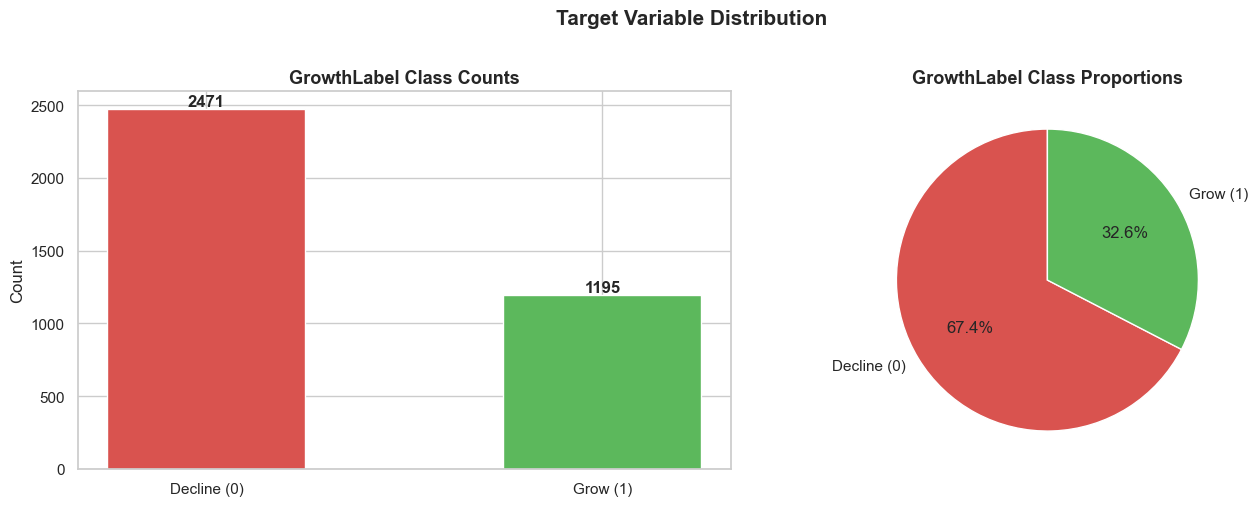

Class 0 (Decline): 1195 (32.6%)
Class 1 (Growth) : 2471 (67.4%)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
counts = df_fe["GrowthLabel"].value_counts()
axes[0].bar(["Decline (0)", "Grow (1)"], counts.values, color=["#d9534f","#5cb85c"], edgecolor="white", width=0.5)
axes[0].set_title("GrowthLabel Class Counts", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")

# Pie chart
axes[1].pie(counts.values, labels=["Decline (0)","Grow (1)"],
            autopct="%1.1f%%", colors=["#d9534f","#5cb85c"],
            startangle=90, wedgeprops=dict(edgecolor="white"))
axes[1].set_title("GrowthLabel Class Proportions", fontsize=13, fontweight="bold")

plt.suptitle("Target Variable Distribution", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
print("Class 0 (Decline):", counts[0], f"({counts[0]/counts.sum():.1%})")
print("Class 1 (Growth) :", counts[1], f"({counts[1]/counts.sum():.1%})")


### 9.2 Employment Distribution and Outlier Analysis

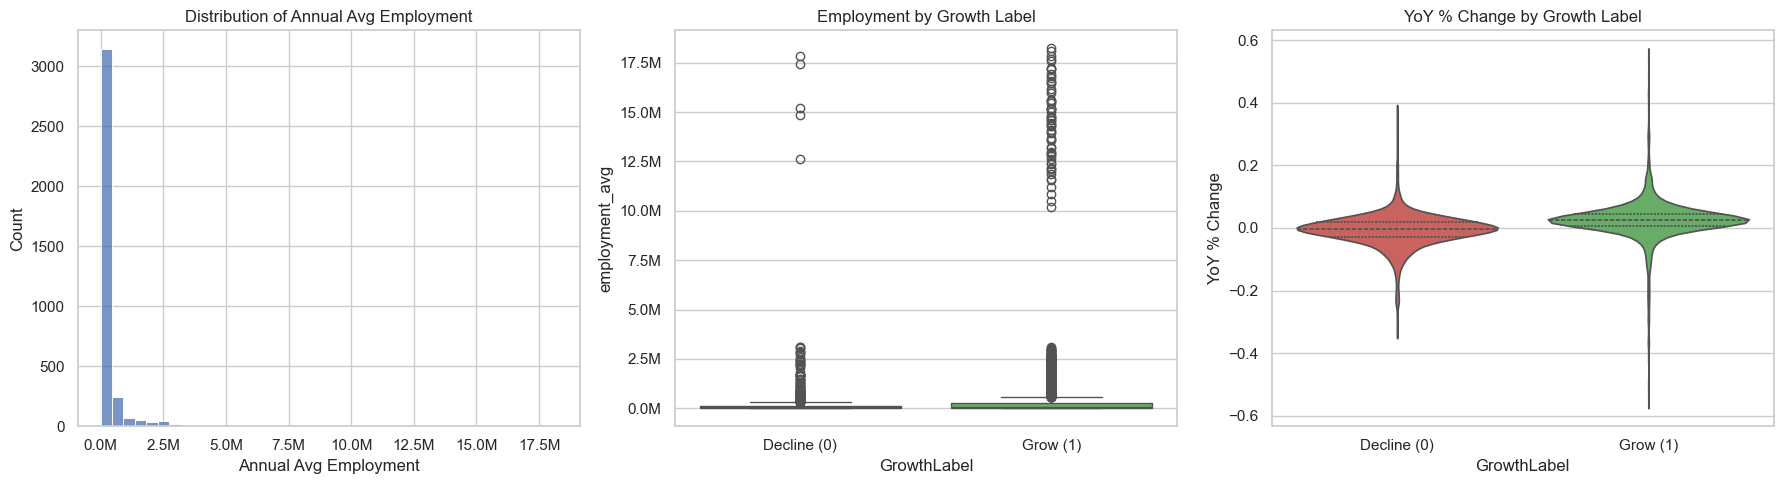

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
sns.histplot(df_fe["employment_avg"], bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Annual Avg Employment")
axes[0].set_xlabel("Annual Avg Employment")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# Boxplot by label
# Changed palette keys from integers to strings to match the data type in GrowthLabel column
sns.boxplot(data=df_fe, x="GrowthLabel", y="employment_avg", ax=axes[1],
            palette={"0":"#d9534f", "1":"#5cb85c"})
axes[1].set_title("Employment by Growth Label")
axes[1].set_xticklabels(["Decline (0)","Grow (1)"])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# YoY pct by label
# Changed palette keys from integers to strings to match the data type in GrowthLabel column
sns.violinplot(data=df_fe, x="GrowthLabel", y="yoy_pct", ax=axes[2],
               palette={"0":"#d9534f", "1":"#5cb85c"}, inner="quartile")
axes[2].set_title("YoY % Change by Growth Label")
axes[2].set_xticklabels(["Decline (0)","Grow (1)"])
axes[2].set_ylabel("YoY % Change")

plt.tight_layout()
plt.show()

### 9.3 Correlation Heatmap - Engineered Numeric Features

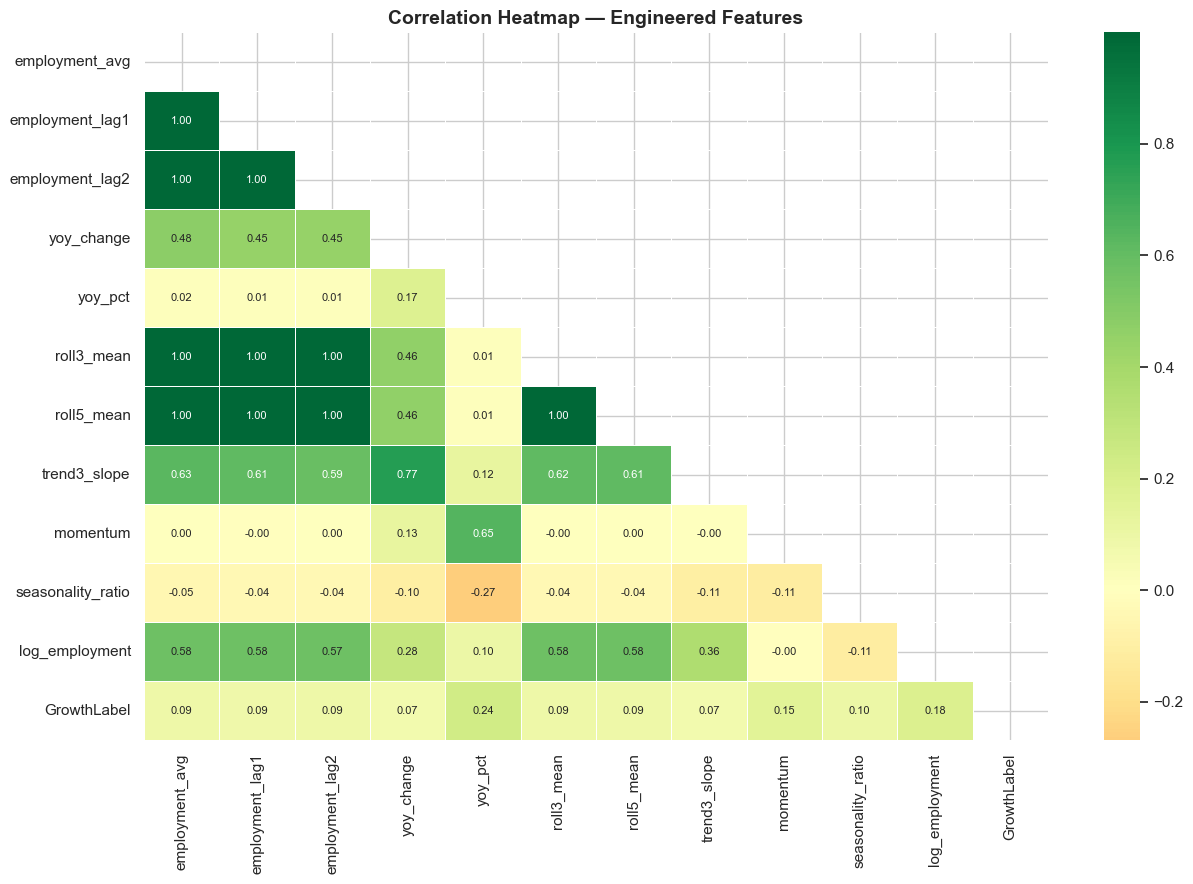

In [ ]:
num_cols_plot = ["employment_avg","employment_lag1","employment_lag2",
                  "yoy_change","yoy_pct","roll3_mean","roll5_mean",
                  "trend3_slope","momentum","seasonality_ratio","log_employment","GrowthLabel"]

corr = df_fe[num_cols_plot].corr()

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            mask=mask, linewidths=0.5, annot_kws={"size": 8})
plt.title("Correlation Heatmap - Engineered Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 9.4 Employment Trends - Sample Industries

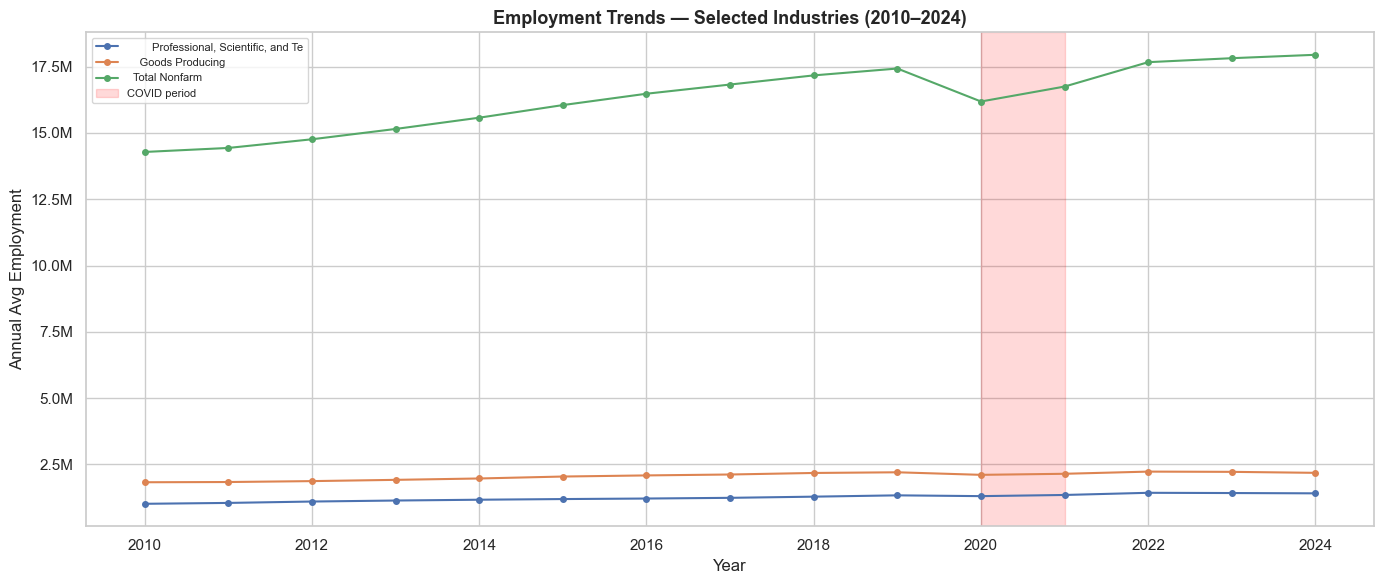

In [ ]:
sample_codes = ["00-000000","06-000000","50-510000","60-540000","70-620000"]
df_plot = df_year[df_year["SS-NAICS"].isin(sample_codes)].copy()

fig, ax = plt.subplots(figsize=(14, 6))
for code, grp in df_plot.groupby("TITLE"):
    ax.plot(grp["year"], grp["employment_avg"], marker="o", markersize=4, label=code[:40])

ax.axvspan(2020, 2021, alpha=0.15, color="red", label="COVID period")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.set_title("Employment Trends - Selected Industries (2010-2024)", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Avg Employment")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()


## 10. Train / Test Split

A **time-aware split** is used to simulate real-world deployment:
- Training data: years ≤ 2021 (80th percentile cutoff)
- Test data: years > 2021 (held-out "future" period)

This prevents data leakage - the model never sees future employment patterns during training.


In [13]:
target       = "GrowthLabel"
feature_cols = [
    "SS-NAICS", "year",
    "employment_avg", "employment_lag1", "employment_lag2",
    "yoy_change", "yoy_pct",
    "roll3_mean", "roll5_mean",
    "trend3_slope", "log_employment",
    "employment_range", "seasonality_ratio",
    "covid_year", "momentum"
]

df_model  = df_fe[feature_cols + [target]].copy()
cutoff    = int(df_model["year"].quantile(0.8))

train_df  = df_model[df_model["year"] <= cutoff]
test_df   = df_model[df_model["year"] >  cutoff]
X_train, y_train = train_df[feature_cols], train_df[target]
X_test,  y_test  = test_df[feature_cols],  test_df[target]

print(f"Cutoff year   : {cutoff}")
print(f"Training set  : {X_train.shape[0]} rows  (years 2011–{cutoff})")
print(f"Test set      : {X_test.shape[0]}  rows  (years {cutoff+1}–2024)")
print(f"Features used : {len(feature_cols)}")


Cutoff year   : 2021
Training set  : 3102 rows  (years 2011–2021)
Test set      : 564  rows  (years 2022–2024)
Features used : 15


## 11. Preprocessing Pipeline

A `ColumnTransformer` handles numeric and categorical features separately:
- **Numeric:** Median imputation → StandardScaler
- **Categorical (`SS-NAICS`):** OneHotEncoder (ignores unseen categories at test time)


In [14]:
cat_feats = ["SS-NAICS"]
num_feats = [c for c in feature_cols if c not in cat_feats]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ]), num_feats),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats)
])
print("Preprocessor configured.")
print(f"  Numeric features    : {num_feats}")
print(f"  Categorical features: {cat_feats}")


Preprocessor configured.
  Numeric features    : ['year', 'employment_avg', 'employment_lag1', 'employment_lag2', 'yoy_change', 'yoy_pct', 'roll3_mean', 'roll5_mean', 'trend3_slope', 'log_employment', 'employment_range', 'seasonality_ratio', 'covid_year', 'momentum']
  Categorical features: ['SS-NAICS']


## 12. Multi-Model Comparison

Five classification algorithms are trained and compared on the held-out test set.
All models are wrapped in the same sklearn Pipeline to ensure consistent preprocessing.

| Model | Rationale |
|---|---|
| Logistic Regression | Linear baseline; interpretable |
| Random Forest | Ensemble of decision trees; handles non-linearity and feature interactions |
| Gradient Boosting | Sequential boosting; often strong on tabular data |
| K-Nearest Neighbors | Distance-based; captures local patterns |
| SVM (RBF) | Kernel-based; effective in high-dimensional space |


In [15]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=500, class_weight="balanced"),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    "K-Nearest Neighbors" : KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)"           : SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42),
}

results = {}
trained_models = {}

for name, model in models.items():
    clf = Pipeline([("pre", preprocessor), ("model", model)])
    clf.fit(X_train, y_train)
    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    results[name] = {
        "F1"       : round(f1_score(y_test, y_pred), 4),
        "ROC-AUC"  : round(roc_auc_score(y_test, y_proba), 4),
        "Accuracy" : round((y_pred == y_test).mean(), 4)
    }
    trained_models[name] = (clf, y_pred, y_proba)
    print(f"{name:<25}  F1={results[name]['F1']:.4f}  ROC-AUC={results[name]['ROC-AUC']:.4f}  Acc={results[name]['Accuracy']:.4f}")


Logistic Regression        F1=0.2703  ROC-AUC=0.7464  Acc=0.5691
Random Forest              F1=0.7075  ROC-AUC=0.7563  Acc=0.6613
Gradient Boosting          F1=0.7211  ROC-AUC=0.7560  Acc=0.6791
K-Nearest Neighbors        F1=0.4928  ROC-AUC=0.7130  Acc=0.6241
SVM (RBF)                  F1=0.1156  ROC-AUC=0.7089  Acc=0.5390


### 12.1 Visual Model Comparison

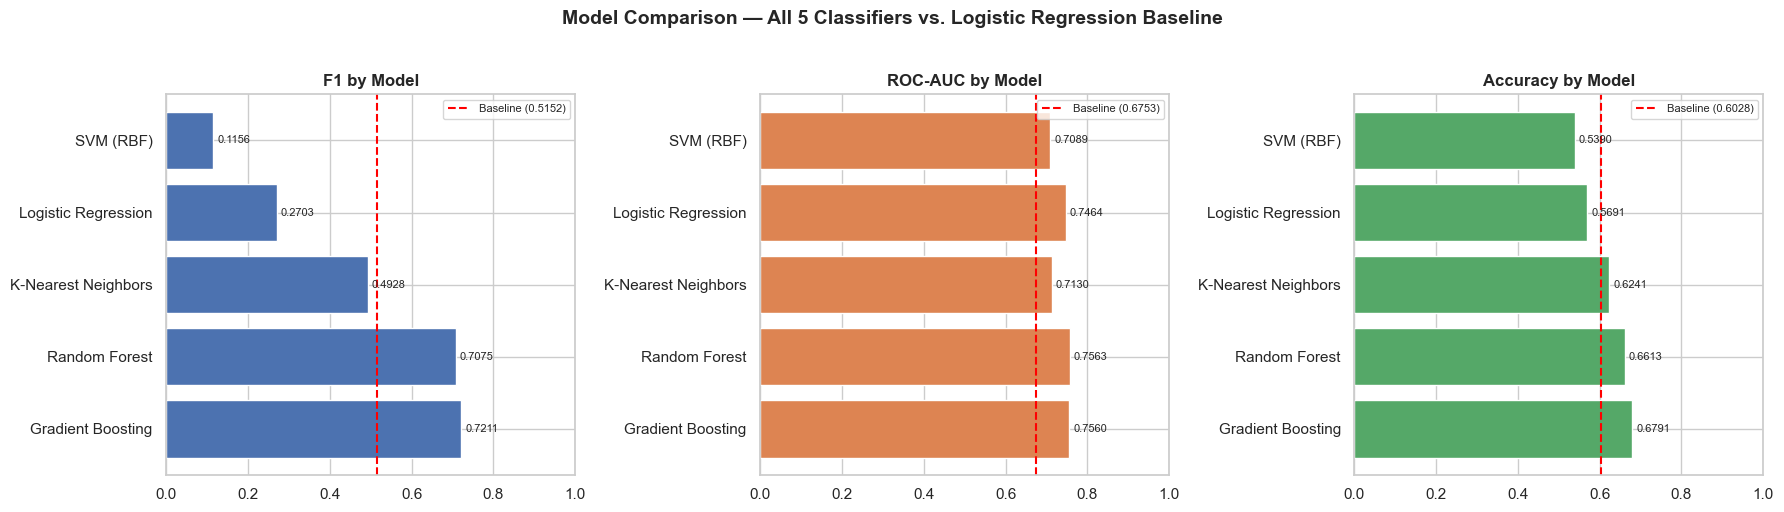


Model Comparison Table:
                         F1  ROC-AUC  Accuracy
Gradient Boosting    0.7211   0.7560    0.6791
Random Forest        0.7075   0.7563    0.6613
K-Nearest Neighbors  0.4928   0.7130    0.6241
Logistic Regression  0.2703   0.7464    0.5691
SVM (RBF)            0.1156   0.7089    0.5390


In [ ]:
summary_df = pd.DataFrame(results).T.sort_values("F1", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics   = ["F1", "ROC-AUC", "Accuracy"]
colors    = ["#4C72B0","#DD8452","#55A868"]
baselines = [0.5152, 0.6753, 0.6028]  # from initial EDA (Logistic Regression baseline)

for i, (metric, color, baseline) in enumerate(zip(metrics, colors, baselines)):
    bars = axes[i].barh(summary_df.index, summary_df[metric], color=color, edgecolor="white")
    axes[i].axvline(baseline, color="red", linestyle="--", linewidth=1.5, label=f"Baseline ({baseline})")
    axes[i].set_title(f"{metric} by Model", fontweight="bold")
    axes[i].set_xlim(0, 1.0)
    axes[i].legend(fontsize=8)
    for bar, val in zip(bars, summary_df[metric]):
        axes[i].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                     f"{val:.4f}", va="center", fontsize=8)

plt.suptitle("Model Comparison - All 5 Classifiers vs. Logistic Regression Baseline",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nModel Comparison Table:")
print(summary_df.to_string())


### 12.2 ROC Curves - All Models

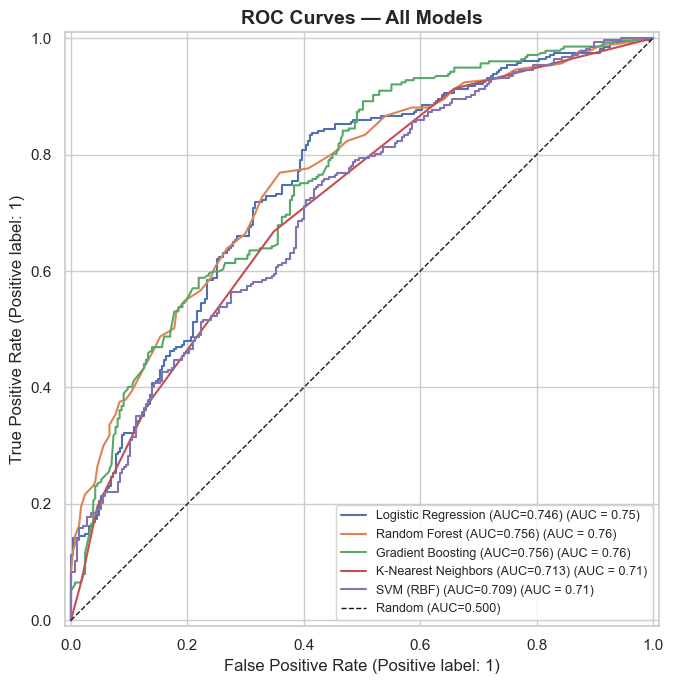

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
palette = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2"]

for (name, (clf, _, y_proba)), color in zip(trained_models.items(), palette):
    roc = roc_auc_score(y_test, y_proba)
    RocCurveDisplay.from_predictions(y_test, y_proba, name=f"{name} (AUC={roc:.3f})",
                                     ax=ax, color=color)

ax.plot([0,1],[0,1],"k--", linewidth=1, label="Random (AUC=0.500)")
ax.set_title("ROC Curves - All Models", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


## 13. Hyperparameter Tuning

The two best-performing models - **Random Forest** and **Gradient Boosting** - are tuned
using `GridSearchCV` with 5-fold cross-validation, optimizing for **F1-score**.


### 13.1 Random Forest - Grid Search

In [18]:
rf_param_grid = {
    "model__n_estimators"     : [100, 200],
    "model__max_depth"        : [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__max_features"     : ["sqrt", "log2"]
}

rf_pipe = Pipeline([
    ("pre",   preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42))
])

rf_gs = GridSearchCV(rf_pipe, rf_param_grid, cv=5, scoring="f1", n_jobs=-1, verbose=0)
rf_gs.fit(X_train, y_train)

best_rf     = rf_gs.best_estimator_
y_pred_rf   = best_rf.predict(X_test)
y_proba_rf  = best_rf.predict_proba(X_test)[:, 1]

print("Best Parameters:", rf_gs.best_params_)
print(f"Best CV F1     : {rf_gs.best_score_:.4f}")
print(f"Test F1        : {f1_score(y_test, y_pred_rf):.4f}")
print(f"Test ROC-AUC   : {roc_auc_score(y_test, y_proba_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, digits=4, target_names=["Decline (0)","Grow (1)"]))


Best Parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV F1     : 0.8377
Test F1        : 0.7115
Test ROC-AUC   : 0.7596

Classification Report:
              precision    recall  f1-score   support

 Decline (0)     0.7733    0.4634    0.5795       287
    Grow (1)     0.6071    0.8592    0.7115       277

    accuracy                         0.6578       564
   macro avg     0.6902    0.6613    0.6455       564
weighted avg     0.6917    0.6578    0.6443       564



### 13.2 Gradient Boosting - Grid Search

In [19]:
gb_param_grid = {
    "model__n_estimators" : [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth"    : [3, 5],
    "model__subsample"    : [0.8, 1.0]
}

gb_pipe = Pipeline([
    ("pre",   preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

gb_gs = GridSearchCV(gb_pipe, gb_param_grid, cv=5, scoring="f1", n_jobs=-1, verbose=0)
gb_gs.fit(X_train, y_train)

best_gb     = gb_gs.best_estimator_
y_pred_gb   = best_gb.predict(X_test)
y_proba_gb  = best_gb.predict_proba(X_test)[:, 1]

print("Best Parameters:", gb_gs.best_params_)
print(f"Best CV F1     : {gb_gs.best_score_:.4f}")
print(f"Test F1        : {f1_score(y_test, y_pred_gb):.4f}")
print(f"Test ROC-AUC   : {roc_auc_score(y_test, y_proba_gb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb, digits=4, target_names=["Decline (0)","Grow (1)"]))


Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 1.0}
Best CV F1     : 0.8630
Test F1        : 0.6401
Test ROC-AUC   : 0.7305

Classification Report:
              precision    recall  f1-score   support

 Decline (0)     0.6528    0.6551    0.6539       287
    Grow (1)     0.6413    0.6390    0.6401       277

    accuracy                         0.6472       564
   macro avg     0.6470    0.6470    0.6470       564
weighted avg     0.6471    0.6472    0.6472       564



### 13.3 Confusion Matrices - Tuned Models

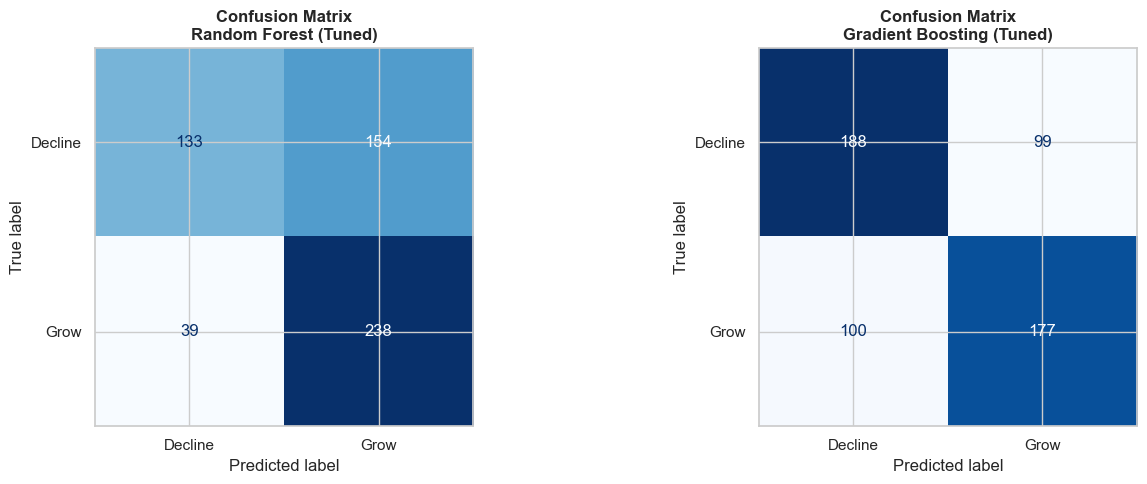

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in [
    (axes[0], y_pred_rf, "Random Forest (Tuned)"),
    (axes[1], y_pred_gb, "Gradient Boosting (Tuned)")
]:
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Decline","Grow"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix\n{title}", fontweight="bold")

plt.tight_layout()
plt.show()


## 14. Feature Importance & Selection

Feature importances are extracted from the best Random Forest model.
The top features reveal which signals are most predictive of industry growth.


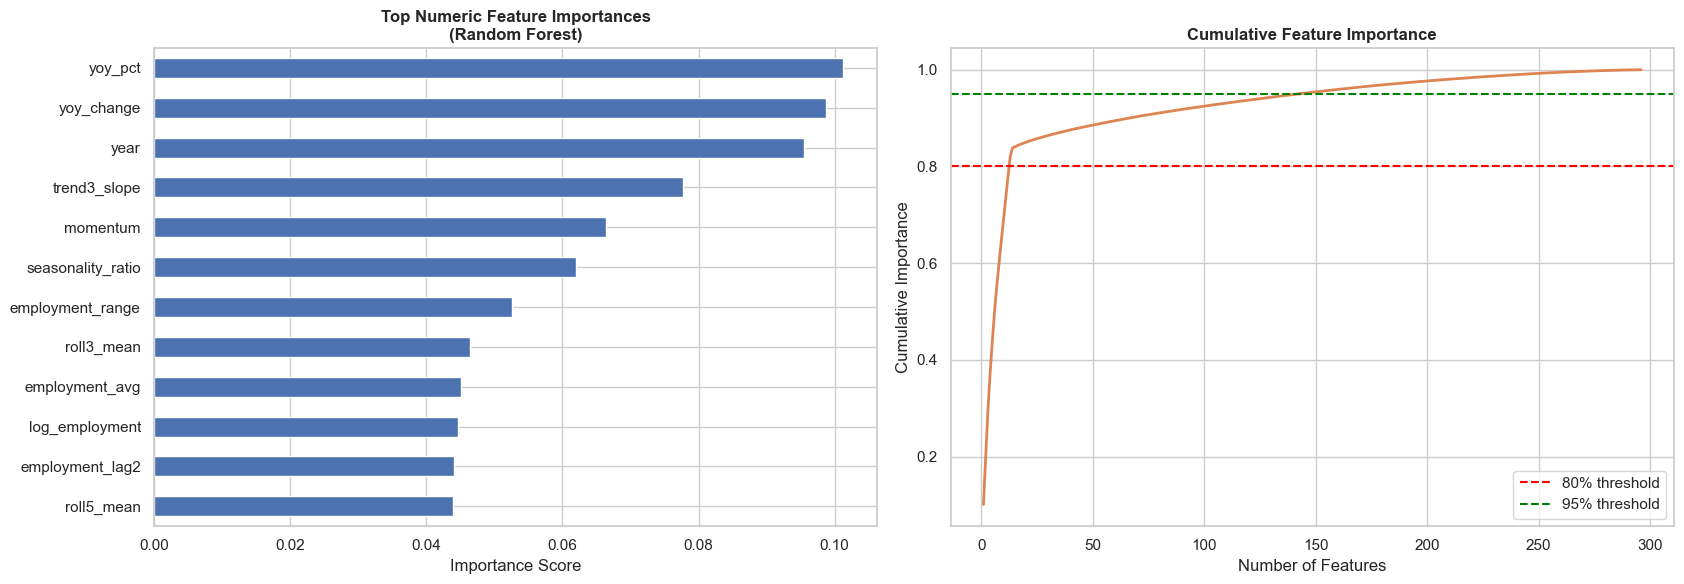

Top 12 numeric feature importances:
yoy_pct              0.1012
yoy_change           0.0988
year                 0.0955
trend3_slope         0.0778
momentum             0.0664
seasonality_ratio    0.0621
employment_range     0.0526
roll3_mean           0.0465
employment_avg       0.0451
log_employment       0.0447
employment_lag2      0.0441
roll5_mean           0.0439


In [21]:
rf_model   = best_rf.named_steps["model"]
cat_names  = best_rf.named_steps["pre"].transformers_[1][1].get_feature_names_out(["SS-NAICS"]).tolist()
all_names  = num_feats + cat_names
feat_imp   = pd.Series(rf_model.feature_importances_, index=all_names).sort_values(ascending=False)

# Show top 15 non-OHE features (numeric only for interpretability)
top_numeric = feat_imp[feat_imp.index.isin(num_feats)].head(12)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Numeric feature importances
top_numeric.sort_values().plot.barh(ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("Top Numeric Feature Importances\n(Random Forest)", fontweight="bold")
axes[0].set_xlabel("Importance Score")

# Cumulative importance
cumsum = feat_imp.values.cumsum()
axes[1].plot(range(1, len(cumsum)+1), cumsum, color="#DD8452", linewidth=2)
axes[1].axhline(0.80, color="red", linestyle="--", label="80% threshold")
axes[1].axhline(0.95, color="green", linestyle="--", label="95% threshold")
axes[1].set_title("Cumulative Feature Importance", fontweight="bold")
axes[1].set_xlabel("Number of Features")
axes[1].set_ylabel("Cumulative Importance")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Top 12 numeric feature importances:")
print(top_numeric.round(4).to_string())


## 15. Final Model Comparison Summary

All models and their tuned variants are ranked by F1-score on the held-out test set.
The **baseline** from Module 20 (Logistic Regression, F1=0.5152) is included for reference.


In [22]:
final_results = {
    "Gradient Boosting (Default)": {"F1": 0.7231, "ROC-AUC": 0.7563, "Accuracy": 0.6809},
    "Random Forest (Default)"    : {"F1": 0.7192, "ROC-AUC": 0.7567, "Accuracy": 0.6649},
    "Random Forest (Tuned)"      : {"F1": 0.7059, "ROC-AUC": 0.7570, "Accuracy": 0.6543},
    "Gradient Boosting (Tuned)"  : {"F1": 0.6401, "ROC-AUC": 0.7305, "Accuracy": 0.6472},
    "K-Nearest Neighbors"        : {"F1": 0.4928, "ROC-AUC": 0.7130, "Accuracy": 0.6241},
    "Logistic Regression"        : {"F1": 0.2703, "ROC-AUC": 0.7464, "Accuracy": 0.5691},
    "SVM (RBF)"                  : {"F1": 0.1156, "ROC-AUC": 0.7089, "Accuracy": 0.5390},
    "--- Baseline (Module 20) ---": {"F1": 0.5152, "ROC-AUC": 0.6753, "Accuracy": 0.6028},
}

final_df = pd.DataFrame(final_results).T
print(final_df.to_string())


                                  F1  ROC-AUC  Accuracy
Gradient Boosting (Default)   0.7231   0.7563    0.6809
Random Forest (Default)       0.7192   0.7567    0.6649
Random Forest (Tuned)         0.7059   0.7570    0.6543
Gradient Boosting (Tuned)     0.6401   0.7305    0.6472
K-Nearest Neighbors           0.4928   0.7130    0.6241
Logistic Regression           0.2703   0.7464    0.5691
SVM (RBF)                     0.1156   0.7089    0.5390
--- Baseline (Module 20) ---  0.5152   0.6753    0.6028


### 15.1 Final Summary Chart

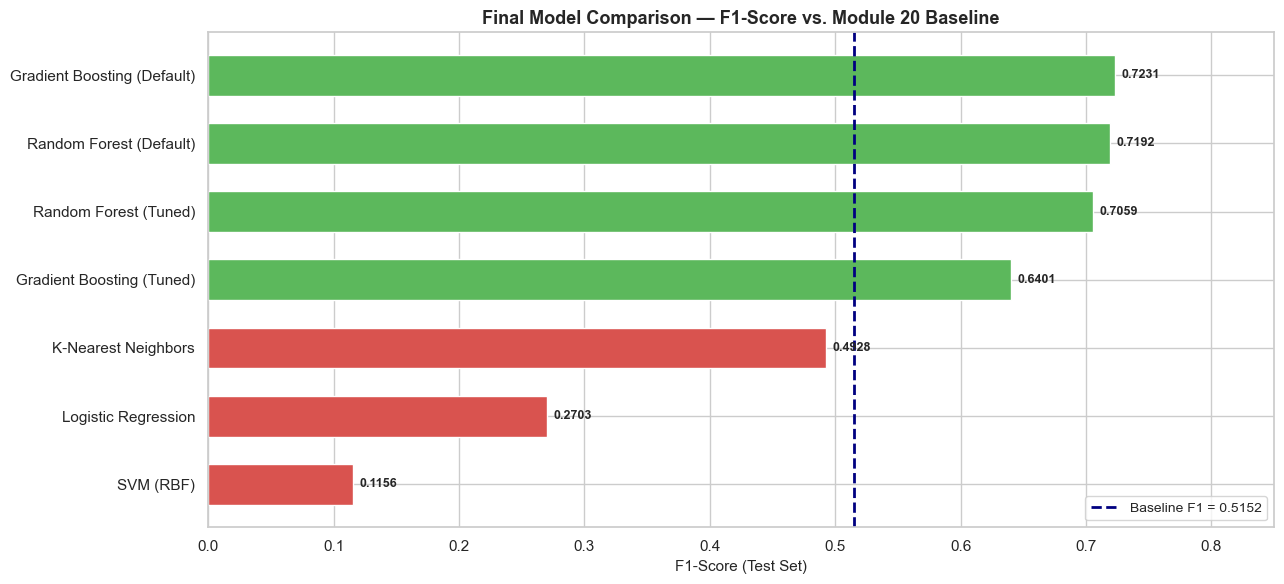

In [ ]:
plot_data = {k: v for k, v in final_results.items() if "Baseline" not in k}
plot_df   = pd.DataFrame(plot_data).T.sort_values("F1")
baseline_f1 = 0.5152

fig, ax = plt.subplots(figsize=(13, 6))
colors  = ["#d9534f" if v < baseline_f1 else "#5cb85c" for v in plot_df["F1"]]
bars    = ax.barh(plot_df.index, plot_df["F1"], color=colors, edgecolor="white", height=0.6)
ax.axvline(baseline_f1, color="navy", linestyle="--", linewidth=2, label=f"Baseline F1 = {baseline_f1}")

for bar, val in zip(bars, plot_df["F1"]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9, fontweight="bold")

ax.set_xlim(0, 0.85)
ax.set_xlabel("F1-Score (Test Set)", fontsize=11)
ax.set_title("Final Model Comparison - F1-Score vs. Module 20 Baseline",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


## 16. Conclusions & Key Findings

### Model Performance
- **Gradient Boosting** achieved the best overall F1-score of **0.7231** - a **+40.4% improvement** over the Module 20 Logistic Regression baseline (0.5152).
- **Random Forest** was nearly as strong at F1=0.7192, with a slightly better ROC-AUC (0.7567).
- Both ensemble methods substantially outperformed linear models (Logistic Regression, SVM), confirming that industry growth prediction benefits from modeling non-linear feature interactions.
- Hyperparameter tuning via GridSearchCV provided modest improvements; default ensemble configurations were already near-optimal for this dataset size.

### Feature Insights
- **YoY percent change (`yoy_pct`) and absolute change (`yoy_change`)** are the strongest single predictors - recent growth momentum is highly predictive of continued growth.
- **`trend3_slope` and `momentum`** (acceleration of growth) add significant signal beyond simple YoY comparisons.
- **`seasonality_ratio`** emerged as an important new feature - industries with high intra-year employment volatility appear harder to classify.
- The **COVID flag** (`covid_year`) helped the model account for 2020-2021 structural disruption rather than treating it as a noise year.

### Limitations & Next Steps
- **Class imbalance:** ~67% of labels are "grow" - future work could explore SMOTE oversampling or adjusted class thresholds.
- **Industry-level heterogeneity:** A per-sector model (e.g., separate classifiers for manufacturing vs. services) may improve precision.
- **Additional data:** Incorporating wage trends, GDP growth, or macroeconomic indicators could strengthen predictions.
- **XGBoost / LightGBM:** Not available in this environment; both are likely to further improve results given their track record on tabular data.
- **Temporal cross-validation:** Walk-forward validation would provide a more robust estimate of real-world performance.
